In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [30]:
df = pd.read_csv("data/learning_traces.13m.csv")
print("Shape:", df.shape)
print(df.head())

KeyboardInterrupt: 

While it may look like a lot of data, it boils down to this number below and even then it does not look like Duolingo is able to retain all these individual customers

In [ ]:
print(
    "We have {} unique users learning {} different words.".format(
        df.user_id.nunique(), df.lexeme_id.nunique()
    )
)

We have 115222 unique users learning 19279 different words.


In [ ]:
df["broad_pos"] = "Other/Grammar"

# use case-insensitive matching
df.loc[df["lexeme_string"].str.contains("<n>", case=False), "broad_pos"] = "Nouns"
df.loc[df["lexeme_string"].str.contains("<vblex>|<vb>", case=False), "broad_pos"] = (
    "Action Verbs"
)
df.loc[df["lexeme_string"].str.contains("<vbdo>", case=False), "broad_pos"] = (
    "Helper Verbs"
)
df.loc[df["lexeme_string"].str.contains("<vbmod>", case=False), "broad_pos"] = (
    "Modal Verbs"
)
df.loc[df["lexeme_string"].str.contains("<vbser>", case=False), "broad_pos"] = (
    "Linking Verbs"
)
df.loc[df["lexeme_string"].str.contains("<prn>", case=False), "broad_pos"] = "Pronouns"
df.loc[df["lexeme_string"].str.contains("<det>", case=False), "broad_pos"] = "Articles"
df.loc[df["lexeme_string"].str.contains("<adj>", case=False), "broad_pos"] = (
    "Adjectives"
)
df.loc[df["lexeme_string"].str.contains("<adv>", case=False), "broad_pos"] = "Adverbs"
df.loc[df["lexeme_string"].str.contains("<ij>", case=False), "broad_pos"] = (
    "Interjection"
)

# catch <pr> but exclude <prn>
df.loc[
    (df["lexeme_string"].str.contains("<pr>", case=False))
    & (~df["lexeme_string"].str.contains("<prn>", case=False)),
    "broad_pos",
] = "Prepositions"

# check the distribution
print(df["broad_pos"].value_counts())

broad_pos
Nouns            5477464
Action Verbs     2235240
Articles         1347633
Pronouns         1045878
Adjectives        711698
Linking Verbs     547420
Adverbs           453558
Other/Grammar     425339
Prepositions      398337
Interjection      130300
Modal Verbs        46893
Helper Verbs       34466
Name: count, dtype: int64


In [ ]:
df["p_recall_clipped"] = df["p_recall"].clip(lower=0.1)

df["frustration_index"] = (df["history_seen"]) / df["p_recall_clipped"]

# Frustration / Clipped Recall
df["word_toxicity"] = df["frustration_index"] / df["p_recall_clipped"]

In [ ]:
# time sorting for session logic
df = df.sort_values(["user_id", "timestamp"])

# 30-minute gap is a session
df["ts_gap"] = df.groupby("user_id")["timestamp"].diff()
df["is_new_session"] = (df["ts_gap"] > 1800) | (df["ts_gap"].isna())
df["session_id_global"] = df["is_new_session"].cumsum()  # Unique across all users

# duration of a Session
session_level = (
    df.groupby(["user_id", "session_id_global"])
    .agg(
        session_start=("timestamp", "min"),
        session_end=("timestamp", "max"),
        words_in_session=("lexeme_id", "count"),
        avg_recall_session=("p_recall_clipped", "mean"),
        avg_frust_session=("frustration_index", "mean"),
        avg_tox_session=("word_toxicity", "mean"),
    )
    .reset_index()
)

# duration in minutes - 1.0 for single-word sessions
session_level["session_duration_mins"] = (
    session_level["session_end"] - session_level["session_start"]
) / 60
session_level["session_duration_mins"] = session_level["session_duration_mins"].clip(
    lower=1.0
)

# User-Level agg
master_df = (
    session_level.groupby("user_id")
    .agg(
        total_sessions=("session_id_global", "nunique"),  # count
        mins_per_session=("session_duration_mins", "mean"),
        words_per_session=("words_in_session", "mean"),
        total_words_seen=("words_in_session", "sum"),
        avg_frustration=("avg_frust_session", "mean"),
        avg_p_recall=("avg_recall_session", "mean"),
        avg_toxicity=("avg_tox_session", "mean"),
        t_min=("session_start", "min"),
        t_max=("session_end", "max"),
    )
    .reset_index()
)

# tenure and churn logic
latest_ts = df["timestamp"].max()
master_df["tenure_days"] = (master_df["t_max"] - master_df["t_min"]) / 86400
master_df["is_churned"] = (latest_ts - master_df["t_max"] > 259200).astype(int)

# 3-day threshold for seasoned users
master_df["segment"] = np.where((master_df["tenure_days"] >= 3), "Exp", "New")

# Efficiency as a way to know who is doing better on avg #unsure whether to actually use it
master_df["efficiency_index"] = master_df["avg_p_recall"] / (
    master_df["avg_toxicity"] + 1
)


summary = (
    master_df.groupby(["segment", "is_churned"])[
        [
            "avg_frustration",
            "words_per_session",
            "mins_per_session",
            "total_sessions",
            "avg_toxicity",
        ]
    ]
    .mean()
    .round(2)
)

In [ ]:
df = df.merge(
    session_level[
        [
            "user_id",
            "session_id_global",
            "session_duration_mins",
            "avg_frust_session",
            "avg_tox_session",
        ]
    ],
    on=["user_id", "session_id_global"],
    how="left",
)

df = df.merge(
    master_df[["user_id", "segment", "is_churned", "tenure_days", "total_sessions"]],
    on="user_id",
    how="left",
)

df.drop(columns=["ts_gap", "is_new_session"], inplace=True, errors="ignore")

In [ ]:
lang_stats = (
    df.groupby("user_id")["learning_language"]
    .agg([("lang_list", lambda x: list(x.unique())), ("lang_count", "nunique")])
    .reset_index()
)

primary_lang = (
    df.groupby("user_id")["learning_language"]
    .agg(lambda x: x.value_counts().index[0])
    .reset_index(name="primary_language")
)

master_df = master_df.merge(lang_stats, on="user_id", how="left")
master_df = master_df.merge(primary_lang, on="user_id", how="left")

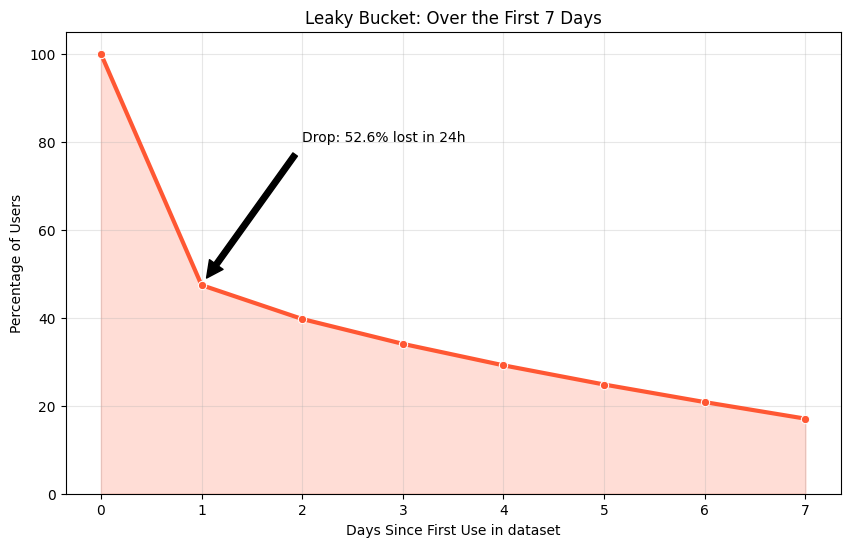

In [ ]:
# how many days each user stayed
master_df["days_active"] = (master_df["t_max"] - master_df["t_min"]) / 86400
master_df["days_active"] = master_df["days_active"].round(0).astype(int)

# count survivors up to Day 7
survival_counts = []
total_users = len(master_df)

for day in range(8):
    survivors = len(master_df[master_df["days_active"] >= day])
    percent = (survivors / total_users) * 100
    survival_counts.append({"Day": day, "Retention_Rate": percent})

survival_df = pd.DataFrame(survival_counts)

# survival Curve
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=survival_df,
    x="Day",
    y="Retention_Rate",
    marker="o",
    linewidth=3,
    color="#FF5733",
)
plt.fill_between(
    survival_df["Day"], survival_df["Retention_Rate"], alpha=0.2, color="#FF5733"
)

plt.annotate(
    f"Drop: {100 - survival_df.iloc[1]['Retention_Rate']:.1f}% lost in 24h",
    xy=(1, survival_df.iloc[1]["Retention_Rate"]),
    xytext=(2, 80),
    arrowprops=dict(facecolor="black", shrink=0.05),
)

plt.title("Leaky Bucket: Over the First 7 Days")
plt.ylabel("Percentage of Users")
plt.xlabel("Days Since First Use in dataset")
plt.ylim(0, 105)
plt.grid(True, alpha=0.3)
plt.savefig("churn_in_first_day.jpg", format="jpg")
plt.show()

over 60% of users stop returning within the first 24 hours and by day 7, less than 20% are still here
maybe there is a different culprit here - Linguistic Friction???
Maybe we are hitting new users with a complexity wall before they've even had a chance to build a habit
also there are different types of users and that difference in behaviour leads to different reasons for the churn possibly

In [ ]:
# timestamps to Date
df["date"] = pd.to_datetime(df["timestamp"], unit="s").dt.date

# unique calendar days per user
calendar_days = df.groupby("user_id")["date"].nunique().reset_index()
calendar_days.columns = ["user_id", "days_active_calendar"]

master_df = master_df.merge(calendar_days, on="user_id", how="left")

# Consistency Score
master_df["consistency_score"] = (
    master_df["total_sessions"] / master_df["days_active_calendar"]
)

In [ ]:
session_dist = (
    master_df.groupby(["days_active_calendar", "total_sessions"])
    .size()
    .reset_index(name="user_count")
)
frequency_matrix = session_dist.pivot(
    index="days_active_calendar", columns="total_sessions", values="user_count"
).fillna(0)
print(frequency_matrix.head(10))  # first 10 days

total_sessions             1        2       3       4       5       6      7   \
days_active_calendar                                                            
1                     53642.0   5399.0   888.0   202.0    35.0     6.0    2.0   
2                       294.0  15757.0  4727.0  1474.0   426.0   193.0   64.0   
3                         0.0    156.0  5994.0  3078.0  1303.0   574.0  249.0   
4                         0.0      3.0    88.0  2799.0  1798.0  1124.0  582.0   
5                         0.0      0.0     2.0    57.0  1280.0  1100.0  746.0   
6                         0.0      0.0     0.0     5.0    33.0   652.0  627.0   
7                         0.0      0.0     0.0     1.0     3.0    11.0  337.0   
8                         0.0      0.0     0.0     0.0     0.0     2.0   11.0   
9                         0.0      0.0     0.0     0.0     0.0     0.0    0.0   
10                        0.0      0.0     0.0     0.0     0.0     0.0    0.0   

total_sessions           8 

In [ ]:
# could it be a cramming issue?? test that as the first hypothesis

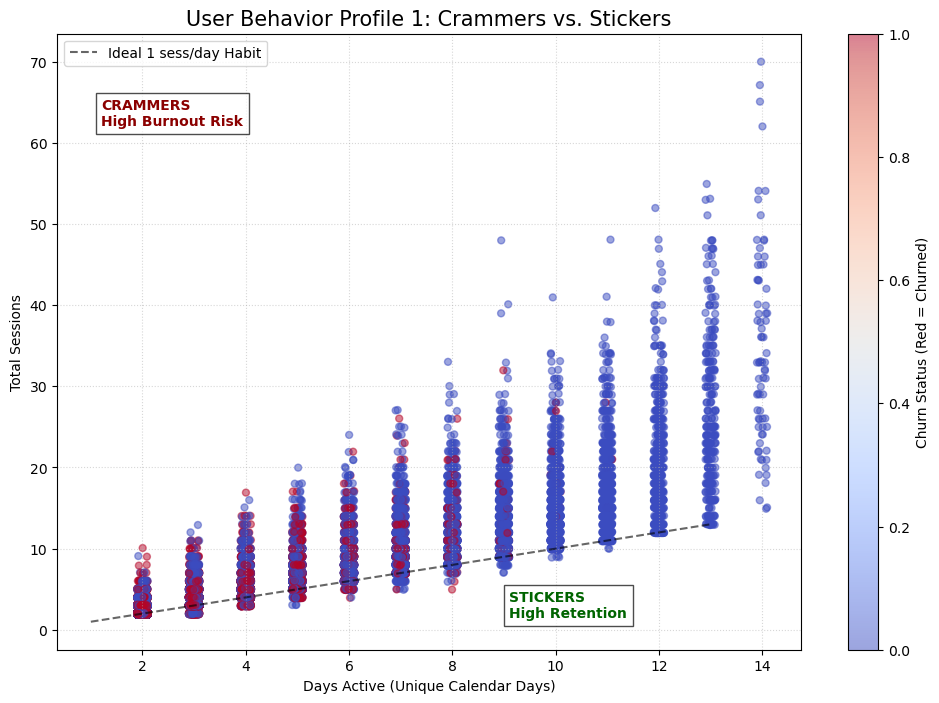

In [ ]:
jitter_x = np.random.uniform(0.9, 1.1, size=len(master_df))
jitter_y = np.random.uniform(0.9, 1.1, size=len(master_df))

plt.figure(figsize=(12, 8))

scatter = plt.scatter(
    master_df["days_active_calendar"] + jitter_x,
    master_df["total_sessions"] + jitter_y,
    c=master_df["is_churned"],
    cmap="coolwarm",
    alpha=0.5,
    s=25,
)

# 1 session per day
max_val = int(master_df["days_active_calendar"].max())
plt.plot(
    [1, max_val],
    [1, max_val],
    color="black",
    linestyle="--",
    alpha=0.6,
    label="Ideal 1 sess/day Habit",
)

plt.text(
    1.2,
    master_df["total_sessions"].max() * 0.9,
    "CRAMMERS\nHigh Burnout Risk",
    color="darkred",
    fontweight="bold",
    bbox=dict(facecolor="white", alpha=0.7),
)

plt.text(
    max_val * 0.7,
    1.5,
    "STICKERS\nHigh Retention",
    color="darkgreen",
    fontweight="bold",
    bbox=dict(facecolor="white", alpha=0.7),
)

plt.title("User Behavior Profile attempt 1: Crammers vs. Stickers", fontsize=15)
plt.xlabel("Days Active (Unique Calendar Days)")

plt.ylabel("Total Sessions")
plt.colorbar(scatter, label="Churn Status (Red = Churned)")
plt.legend()
plt.grid(True, linestyle=":", alpha=0.5)
plt.show()

the graph doesn't give a clear picture so maybe try a different approach

In [ ]:
# group by Segment and Churn to see user profile
churn_analysis = (
    master_df.groupby(["segment", "is_churned"])
    .agg(
        {
            "avg_frustration": "mean",
            "words_per_session": "mean",
            "mins_per_session": "mean",
            "total_sessions": "mean",
            "avg_toxicity": "mean",
        }
    )
    .round(2)
)

churn_analysis

avg_frustration  words_per_session  mins_per_session  \
segment is_churned                                                         
Exp     0                     18.79              38.93             11.18   
        1                     15.34              35.73              9.96   
New     0                     10.30              27.31              8.09   
        1                     11.25              26.91              7.15   

                    total_sessions  avg_toxicity  
segment is_churned                                
Exp     0                     7.01         81.28  
        1                     4.34         64.47  
New     0                     1.69         39.11  
        1                     1.49         44.68

For both types of users, frustration is a differentiator between staying and leaving.
for a new user, even a small increase in friction is enough to make them quit.
Experienced churners seem to be highly committed so maybe the cognitive load became too much
Newbies who quit are doing shorter sessions with higher frustration -  "hitting a wall" early in their session and closing the app out of annoyance. 

Experienced survivors have higher frustration than Experienced quitters
gritty ones tolerate more pain (20.74) than those who quit (16.90) and are quitting because they’ve lost momentum

Newbies are highly sensitive. A 1-point increase leads to churn

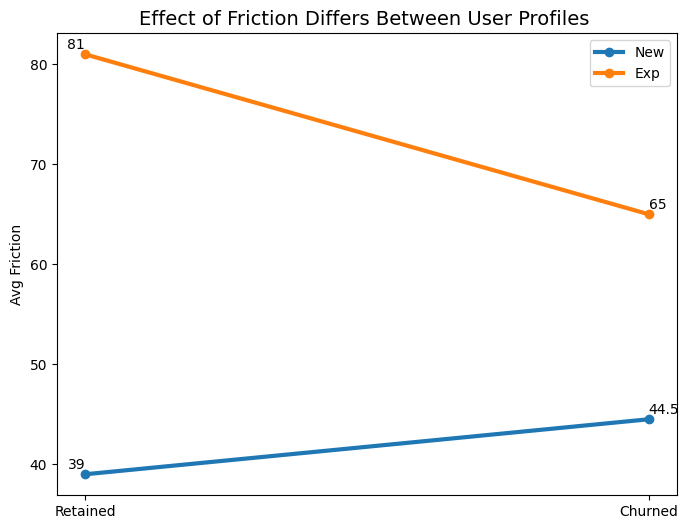

In [ ]:
import matplotlib.pyplot as plt

# plot the number of users as well here 1!!!!!!
# Data from your results
segments = ["New", "Exp"]
retained_frust = [39, 81]
churned_frust = [44.5, 65]

plt.figure(figsize=(8, 6))
for i in range(len(segments)):
    plt.plot(
        ["Retained", "Churned"],
        [retained_frust[i], churned_frust[i]],
        marker="o",
        label=segments[i],
        linewidth=3,
    )
    # Add text labels for values
    plt.text("Retained", retained_frust[i] + 0.5, f"{retained_frust[i]}", ha="right")
    plt.text("Churned", churned_frust[i] + 0.5, f"{churned_frust[i]}", ha="left")

plt.title("Effect of Friction Differs Between User Profiles ", fontsize=14)
plt.ylabel("Avg Friction")
plt.legend()
plt.savefig("Effect of Friction Between Users.jpg", dpi=300)
plt.show()

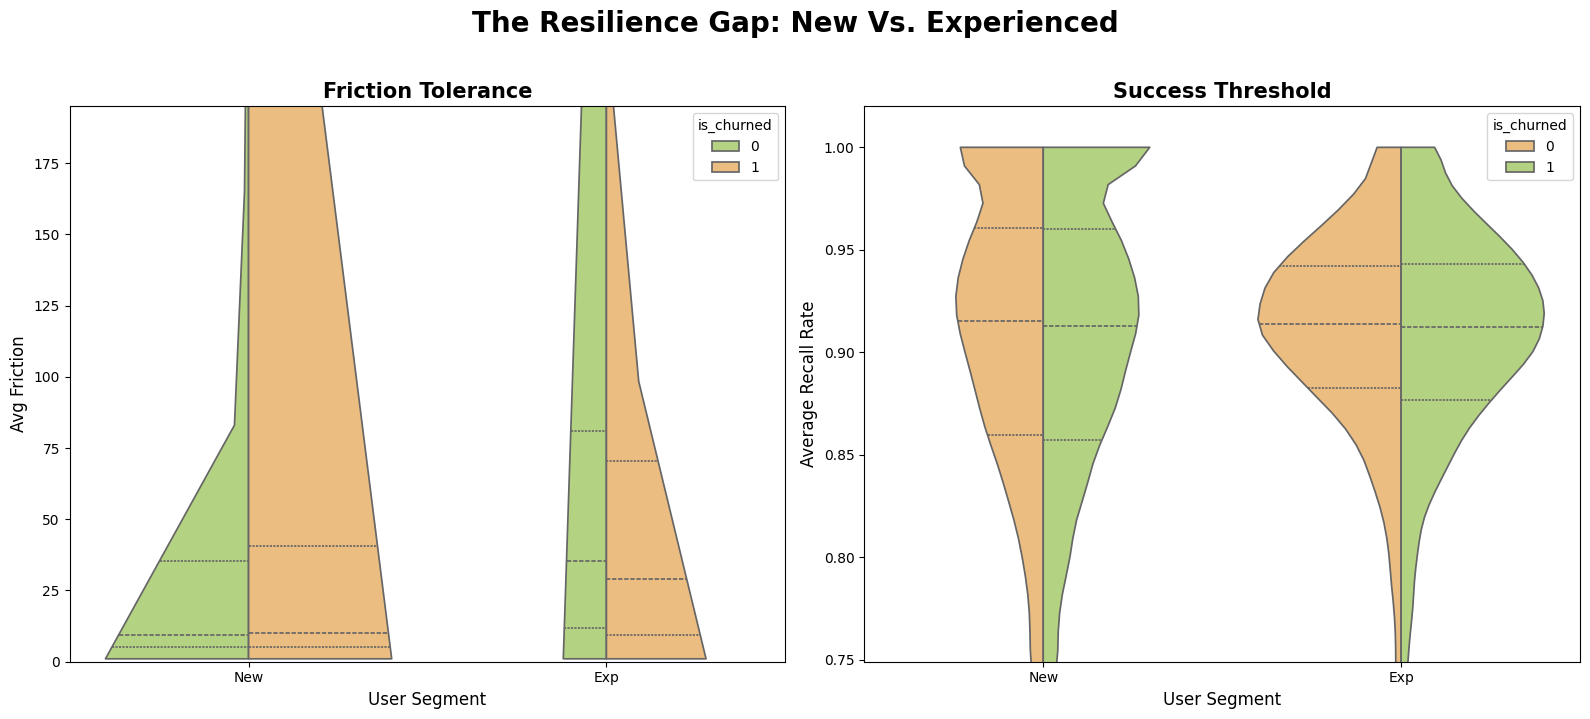

In [ ]:
# 2. Calculate adaptive limits to ensure the 'bulge' is the focus
frust_limit = master_df["avg_toxicity"].quantile(0.95)
recall_limit = master_df["avg_p_recall"].quantile(0.05)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Panel 1: Frustration (The Pain)
sns.violinplot(
    data=master_df,
    x="segment",
    y="avg_toxicity",
    hue="is_churned",
    split=True,
    inner="quart",
    palette="RdYlGn_r",
    ax=axes[0],
    cut=0,
)
axes[0].set_ylim(-0.02, frust_limit)
axes[0].set_title("Friction Tolerance", fontsize=15, fontweight="bold")
axes[0].set_xlabel("User Segment", fontsize=12)
axes[0].set_ylabel("Avg Friction", fontsize=12)

# Panel 2: Success (The Fuel)
sns.violinplot(
    data=master_df,
    x="segment",
    y="avg_p_recall",
    hue="is_churned",
    split=True,
    inner="quart",
    palette="RdYlGn",
    ax=axes[1],
    cut=0,
)
axes[1].set_ylim(recall_limit, 1.02)
axes[1].set_title("Success Threshold", fontsize=15, fontweight="bold")
axes[1].set_xlabel("User Segment", fontsize=12)
axes[1].set_ylabel("Average Recall Rate", fontsize=12)

plt.suptitle(
    "The Resilience Gap: New Vs. Experienced", fontsize=20, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig("resilience_gap_new_vs_exp.jpg", dpi=300, bbox_inches="tight")
plt.show()

For new users, the "Stay" side is pinned almost entirely at the bottom meaning a newbie can only survive if their frustration is very low whereas for experienced it is much fatter at higher levels of frustration
The green bulge is at the very top meaning for a beginner, success is crucial. If their recall drops even to 0.8, they move into the "Churn" side of the violin
For experienced users we see green density much lower down the axis meaning they can fail more often and still keep their streak alive


In [ ]:
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler


def perform_behavioral_clustering(data, segment_label):
    subset = data[data["segment"] == segment_label].copy()
    subset["log_total_words"] = np.log1p(subset["words_per_session"])

    features = ["avg_p_recall", "avg_frustration", "log_total_words"]
    X = subset[features].fillna(0)

    # 3. Scale and Cluster
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Using 3 clusters to find "Low, Mid, and High" engagement profiles
    model = GaussianMixture(n_components=3, random_state=42)
    subset["archetype_id"] = model.fit_predict(X_scaled)

    return subset


# Execute
newbie_clustered = perform_behavioral_clustering(master_df, "New")
exp_clustered = perform_behavioral_clustering(master_df, "Exp")

# 2. Print Results with Proper Interpretation
print("NEWBIE ARCHETYPES")
print(
    newbie_clustered.groupby("archetype_id")[
        ["avg_frustration", "avg_p_recall", "is_churned"]
    ]
    .mean()
    .sort_values("avg_frustration")
)

print("\nEXPERIENCED ARCHETYPES")
print(
    exp_clustered.groupby("archetype_id")[
        ["avg_frustration", "avg_p_recall", "is_churned"]
    ]
    .mean()
    .sort_values("avg_frustration")
)

NEWBIE ARCHETYPES
              avg_frustration  avg_p_recall  is_churned
archetype_id                                           
1                    6.565722      0.917276    0.696391
0                   28.703677      0.806751    0.739232
2                 4178.000000      0.397973    1.000000

EXPERIENCED ARCHETYPES
              avg_frustration  avg_p_recall  is_churned
archetype_id                                           
0                    8.137554      0.915414    0.340079
1                   26.386138      0.898514    0.299766
2                  103.941704      0.790314    0.283753


In [ ]:
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler


def perform_behavioral_clustering(data, segment_label, n_clusters=3):
    subset = data[data["segment"] == segment_label].copy()
    subset["log_total_words"] = np.log1p(subset.get("words_per_session", 0))
    features = ["avg_p_recall", "avg_toxicity", "log_total_words"]
    X = subset[features].fillna(0)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    model = GaussianMixture(n_components=n_clusters, random_state=42)
    subset["archetype_id"] = model.fit_predict(X_scaled)

    return subset


newbie_clustered = perform_behavioral_clustering(master_df, "New", n_clusters=2)
exp_clustered = perform_behavioral_clustering(master_df, "Exp", n_clusters=2)

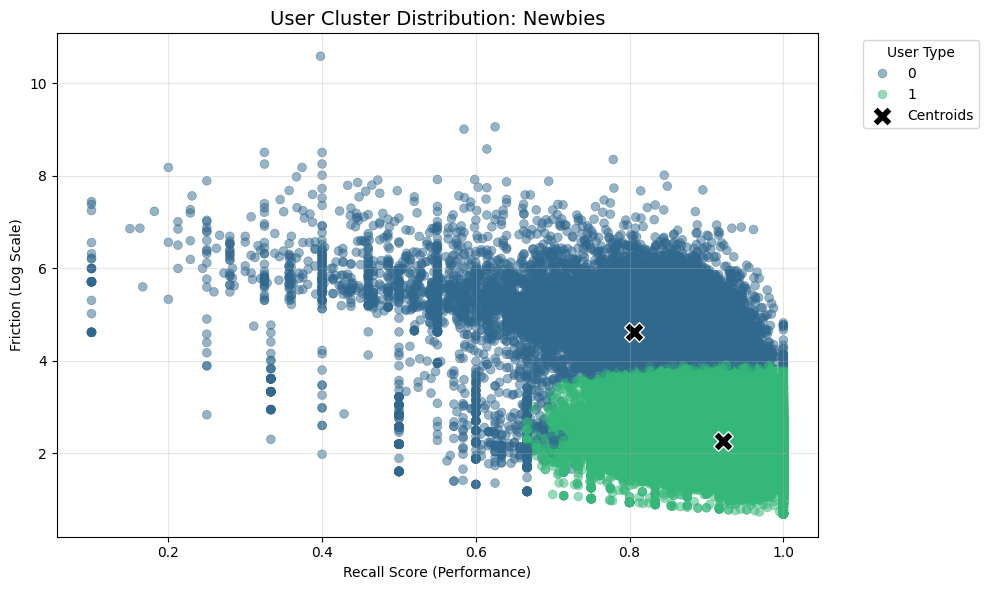

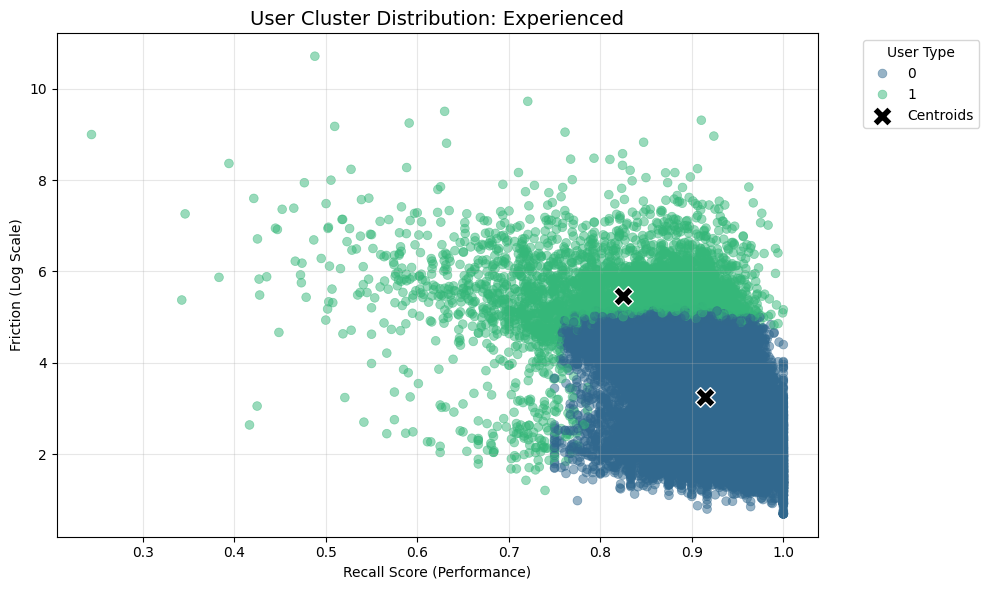

In [ ]:
def plot_raw_clusters(df, title):
    plt.figure(figsize=(10, 6))

    df["log_toxicity"] = np.log1p(df["avg_toxicity"])

    sns.scatterplot(
        data=df,
        x="avg_p_recall",
        y="log_toxicity",
        hue="archetype_id",
        palette="viridis",
        alpha=0.5,
        edgecolor=None,
        s=40,
    )

    # Add  Centroids
    centroids = df.groupby("archetype_id")[["avg_p_recall", "log_toxicity"]].mean()
    plt.scatter(
        centroids["avg_p_recall"],
        centroids["log_toxicity"],
        marker="X",
        s=200,
        color="black",
        label="Centroids",
        edgecolor="white",
    )

    plt.title(f"User Cluster Distribution: {title}", fontsize=14)
    plt.xlabel("Recall Score (Performance)")
    plt.ylabel("Friction (Log Scale)")
    plt.legend(title="User Type", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_raw_clusters(newbie_clustered, "Newbies")
plot_raw_clusters(exp_clustered, "Experienced")

**New**
- 1 - Pure Beginner  - Low to medium frustration (7.1), decent recall (91%) still 70% churn - maybe haven't found value in it yet?
- 0 - Struggler      - High frustration and very low recall leading to quitting immediately
- 
**Experienced** 
- 0 - Casual Habit - Low to moderate frustration and Churn is low (~30-33%)
- 1 - Grinders     - High frustration but lowest churn (27%) frustrated, but have invested so much time that they refuse to quit


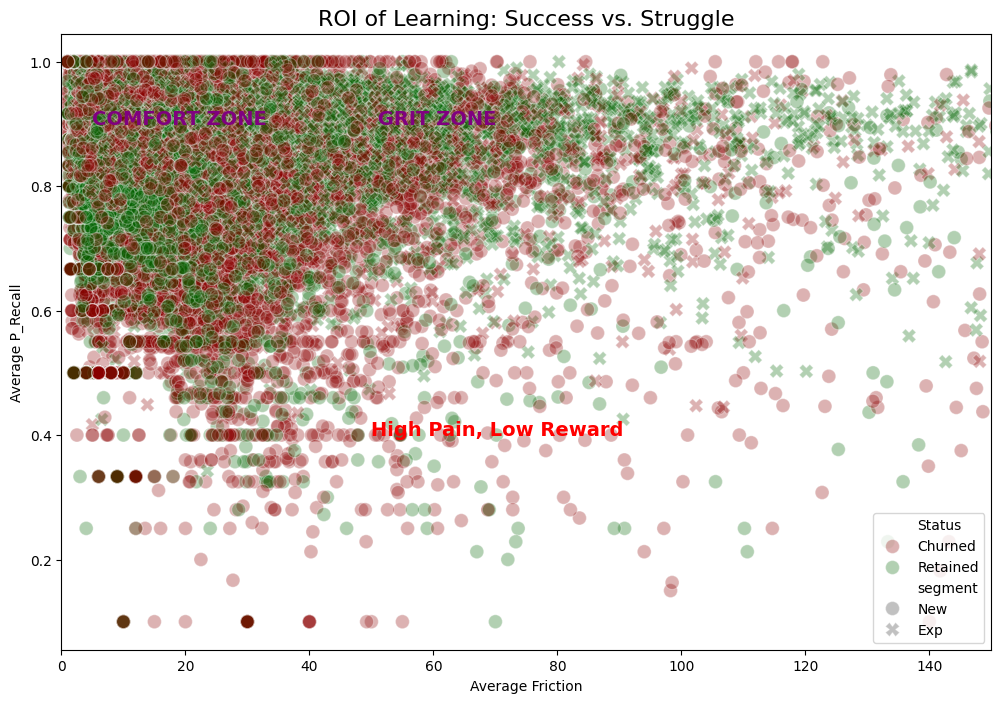

In [ ]:
plot_df = master_df.copy()
plot_df["Status"] = plot_df["is_churned"].map({0: "Retained", 1: "Churned"})

plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=plot_df,
    x="avg_frustration",
    y="avg_p_recall",
    hue="Status",
    style="segment",
    palette={"Retained": "darkgreen", "Churned": "darkred"},
    alpha=0.3,
    s=100,
)

plt.text(50, 0.4, "High Pain, Low Reward", color="red", fontweight="bold", fontsize=14)
plt.text(5, 0.9, "COMFORT ZONE", color="purple", fontweight="bold", fontsize=14)
plt.text(50, 0.9, " GRIT ZONE", color="purple", fontweight="bold", fontsize=14)

plt.title("ROI of Learning: Success vs. Struggle", fontsize=16)
plt.xlabel("Average Friction")
plt.ylabel("Average P_Recall")
plt.xlim(0, 150)
plt.show()

all users are different and we can see here that in the top left and right zones which categorise comfort and power-user territory, more people are retained because the payoff still makes sense whereas in the lower quadrants the pain outweighs the reward leading to more red or chirn

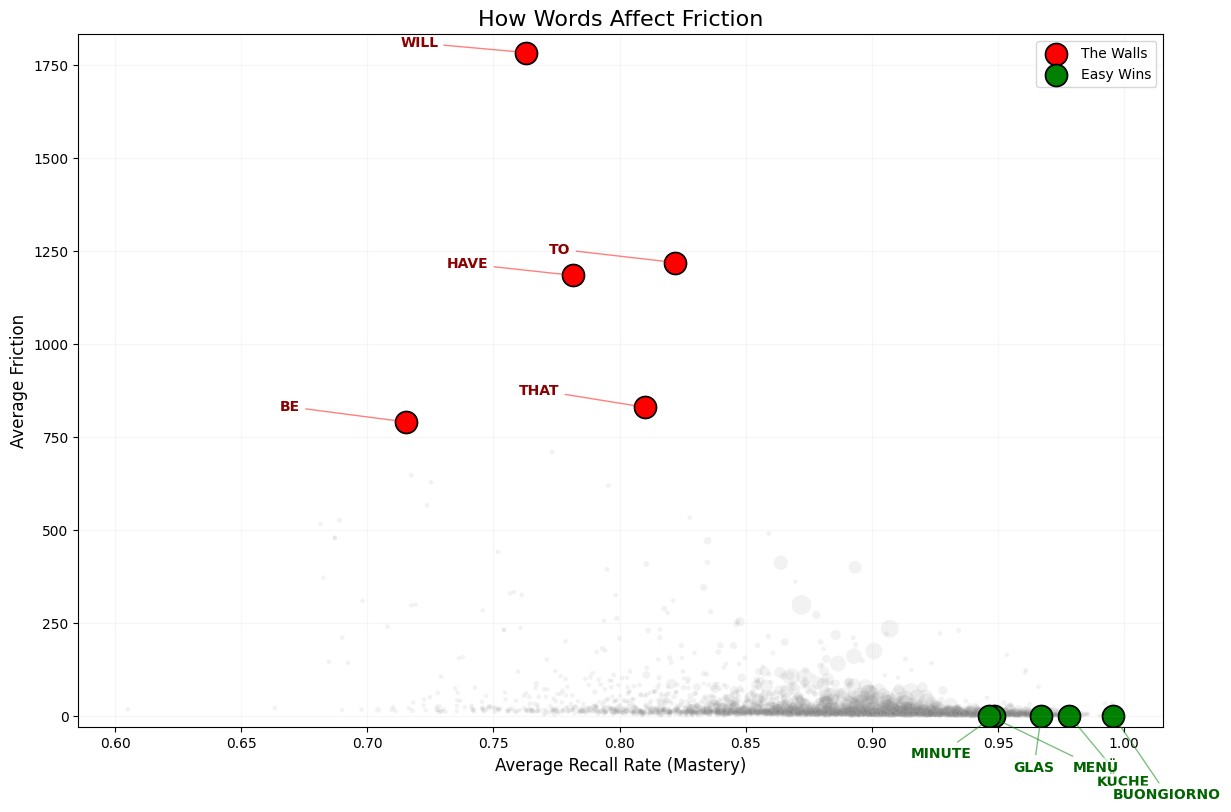

In [ ]:
# get readable words
def clean_word(lex):
    try:
        return lex.split("/")[1].split("<")[0]
    except:
        return lex


df["word_clean"] = df["lexeme_string"].apply(clean_word)

# Aggregate stats by Word
word_map = (
    df.groupby(["lexeme_string", "word_clean"])
    .agg({"p_recall": "mean", "frustration_index": "mean", "user_id": "nunique"})
    .reset_index()
)

# words seen by at least 100 users for statistical significance
word_map = word_map[word_map["user_id"] >= 100].copy()
word_map["toxic_score"] = word_map["frustration_index"] / word_map["p_recall"]

# toxic_score is an Exponential Penalty for Failure by squaring the p_recall in the denominator
# use to separate words into two categories
# Speedbumps (High Frustration, Low Toxicity):These are words like "the" or "is." You see them 1,000 times and get them right 99% of the time
# Frustration is high because of the volume, but the Toxicity is low because you aren't failing them.
# Walls (High Toxicity) words the user has seen 20 times but misses 50% of the time
# words that make a user feel "stupid" and lead to the Boredom/Burnout churn
# "Toxic" Word: High Frustration (0.9) / Low Recall (0.1) = Score 9.0 (Pain)
# "Healthy Challenge": High Frustration (0.8) / High Recall (0.8) = Score 1.0 (Hard but rewarding)
# "Easy Win": Low Frustration (0.1) / High Recall (0.9) = Score 0.11 Easy

toxic_top_5 = word_map.sort_values("toxic_score", ascending=False).head(5)
healthy_bottom_5 = word_map.sort_values("toxic_score", ascending=True).head(5)

plt.figure(figsize=(14, 9))

sns.scatterplot(
    data=word_map,
    x="p_recall",
    y="frustration_index",
    alpha=0.1,
    color="gray",
    size="user_id",
    sizes=(10, 200),
    legend=False,
)

sns.scatterplot(
    data=toxic_top_5,
    x="p_recall",
    y="frustration_index",
    color="red",
    s=250,
    edgecolor="black",
    label="The Walls",
)

sns.scatterplot(
    data=healthy_bottom_5,
    x="p_recall",
    y="frustration_index",
    color="green",
    s=250,
    edgecolor="black",
    label="Easy Wins",
)

for i, row in toxic_top_5.reset_index().iterrows():
    plt.annotate(
        row["word_clean"].upper(),
        xy=(row["p_recall"], row["frustration_index"]),
        xytext=(row["p_recall"] - 0.05, row["frustration_index"] + 15 + (i * 5)),
        arrowprops=dict(arrowstyle="->", color="red", lw=1, alpha=0.5),
        fontsize=10,
        fontweight="bold",
        color="darkred",
    )
# to spread word labels apart
offsets = [(-20, -40), (20, -50), (-60, -30), (60, -40), (0, -60)]

for i, (idx, row) in enumerate(healthy_bottom_5.iterrows()):
    plt.annotate(
        row["word_clean"].upper(),
        xy=(row["p_recall"], row["frustration_index"]),
        xytext=offsets[i],
        textcoords="offset points",
        arrowprops=dict(arrowstyle="->", color="green", lw=1, alpha=0.5),
        fontsize=10,
        fontweight="bold",
        color="darkgreen",
        bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.6, ec="none"),
    )

plt.ylim(
    word_map["frustration_index"].min() - 30, word_map["frustration_index"].max() + 50
)

plt.title("How Words Affect Friction", fontsize=16)
plt.xlabel("Average Recall Rate (Mastery)", fontsize=12)
plt.ylabel("Average Friction", fontsize=12)
plt.grid(alpha=0.1)
plt.savefig("Toxicity_Words.jpg", dpi=300, bbox_inches="tight")
plt.show()

similarly not all words are equal with some leading to more frustration for users

toxic_score = frustration_index / p_recall quantifies Cognitive Debt.

When a word has a high toxic score, it represents a moment where the user’s momentum is halted. They aren't just getting it wrong; they are getting it wrong so often that the reward center of their brain (dopamine from getting a correct answer) is being replaced by pain.

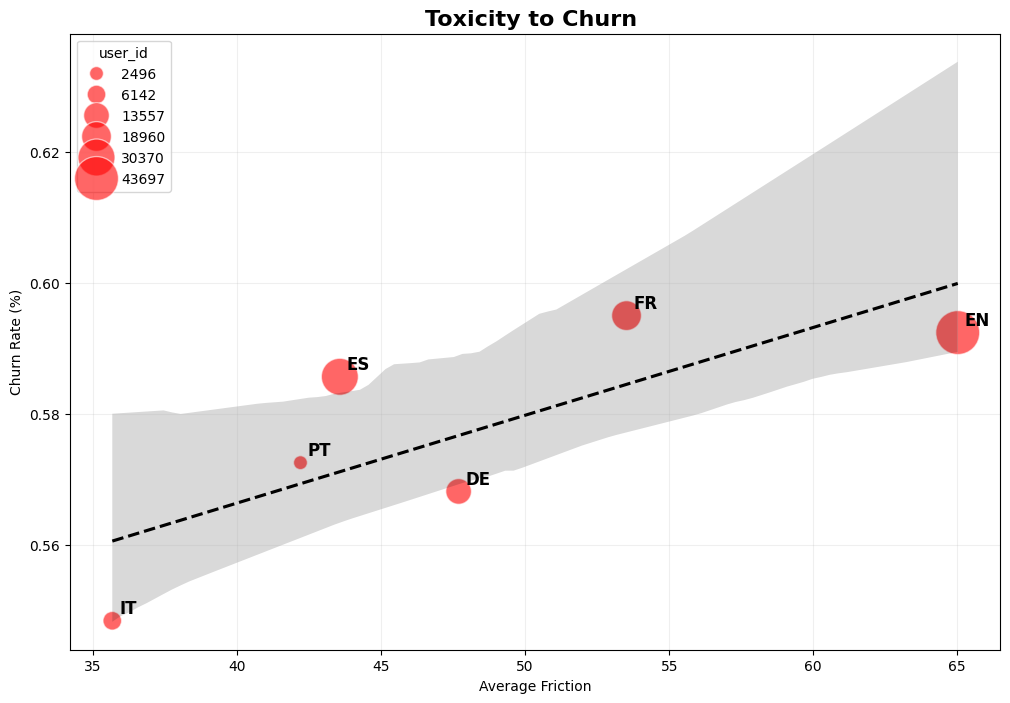

In [ ]:
plt.figure(figsize=(12, 8))

# Aggregate data
lang_summary = (
    master_df.groupby("primary_language")
    .agg({"is_churned": "mean", "avg_toxicity": "mean", "user_id": "nunique"})
    .reset_index()
    .query("user_id > 100")
)

# Size the dots by the number of users
sns.scatterplot(
    data=lang_summary,
    x="avg_toxicity",
    y="is_churned",
    size="user_id",
    sizes=(100, 1000),
    alpha=0.6,
    color="red",
)

sns.regplot(
    data=lang_summary,
    x="avg_toxicity",
    y="is_churned",
    scatter=False,
    color="black",
    line_kws={"linestyle": "--"},
)

for i, txt in enumerate(lang_summary["primary_language"]):
    plt.annotate(
        txt.upper(),
        (lang_summary["avg_toxicity"].iloc[i], lang_summary["is_churned"].iloc[i]),
        fontsize=12,
        fontweight="bold",
        xytext=(5, 5),
        textcoords="offset points",
    )

plt.title("Toxicity to Churn ", fontsize=16, fontweight="bold")
plt.xlabel("Average Friction")
plt.ylabel("Churn Rate (%)")
plt.grid(True, alpha=0.2)
plt.show()

red line represents the relationship between difficulty and user retention 

In [ ]:
# 1. Aggregate metrics by Broad POS
pos_risk_profile = (
    df.groupby("broad_pos")
    .agg({"word_toxicity": "mean", "user_id": "count", "is_churned": "mean"})
    .rename(
        columns={
            "word_toxicity": "avg_toxicity",
            "user_id": "total_exposure",
            "is_churned": "churn_rate",
        }
    )
    .reset_index()
)

pos_risk_profile["exposure_weight"] = (
    pos_risk_profile["total_exposure"] / pos_risk_profile["total_exposure"].max()
) * 2000

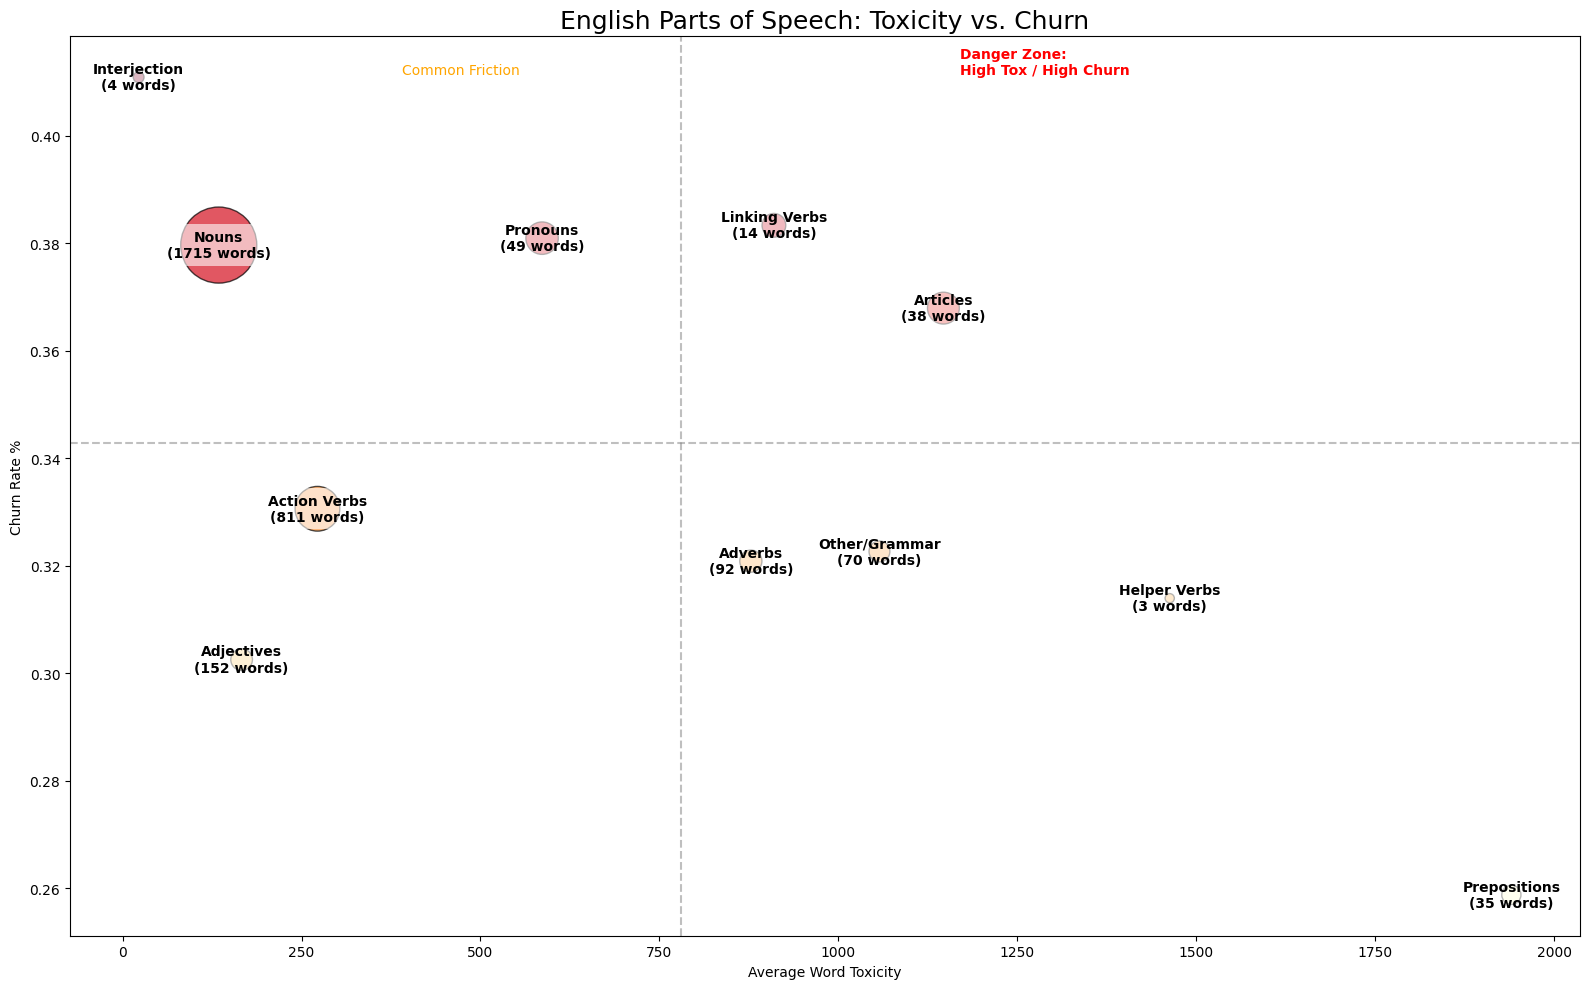

In [ ]:
en_df = df[df["learning_language"] == "en"].copy()

en_pos_risk = (
    en_df.groupby("broad_pos")
    .agg(
        {
            "word_toxicity": "mean",
            "is_churned": "mean",
            "lexeme_string": "nunique",  # vocabulary size
            "user_id": "count",  # total interactions
        }
    )
    .rename(
        columns={
            "word_toxicity": "avg_toxicity",
            "is_churned": "churn_rate",
            "lexeme_string": "unique_word_count",
            "user_id": "total_exposure",
        }
    )
    .reset_index()
)

en_pos_risk["exposure_weight"] = (
    en_pos_risk["total_exposure"] / en_pos_risk["total_exposure"].max()
) * 3000

plt.figure(figsize=(16, 10))

mean_tox = en_pos_risk["avg_toxicity"].mean()
mean_churn = en_pos_risk["churn_rate"].mean()

scatter = plt.scatter(
    data=en_pos_risk,
    x="avg_toxicity",
    y="churn_rate",
    s="exposure_weight",
    c="churn_rate",
    cmap="YlOrRd",
    alpha=0.7,
    edgecolors="black",
)

for i, row in en_pos_risk.iterrows():
    label = f"{row['broad_pos']}\n({row['unique_word_count']} words)"
    plt.text(
        row["avg_toxicity"],
        row["churn_rate"],
        label,
        fontsize=10,
        ha="center",
        va="center",
        fontweight="bold",
        bbox=dict(facecolor="white", alpha=0.6, edgecolor="none"),
    )

plt.axvline(mean_tox, color="gray", linestyle="--", alpha=0.5)
plt.axhline(mean_churn, color="gray", linestyle="--", alpha=0.5)
plt.text(
    mean_tox * 1.5,
    mean_churn * 1.2,
    "Danger Zone:\nHigh Tox / High Churn",
    color="red",
    fontweight="bold",
)
plt.text(mean_tox * 0.5, mean_churn * 1.2, "Common Friction", color="orange")


plt.title("English Parts of Speech: Toxicity vs. Churn", fontsize=18)
plt.xlabel("Average Word Toxicity")
plt.ylabel("Churn Rate %")
plt.tight_layout()
plt.savefig("eng_pos.jpg", dpi=300, bbox_inches="tight")
plt.show()


Interjections - While exposure is relatively low, these words are often culturally specific. 
Linking Verbs - Words like is, am, are, seem have high toxicity and high churn because they are used in almost every sentence, a failure to retain them creates a compounding error effect 
Pronouns - massive exposure and if users are struggling with he/she/they/it, they are facing friction in over 30% of total experience.

Nouns have the highest exposure and moderate churn forming the weight of the language. Users expect them so maybe that is why churn rate is lower than Pronouns or Linking Verbs. 

Articles (a, an, the) have high friction and churn since they involve complex gender or case rules. 

Modal Verbs and Prepositions are the safest because likely by the time users reach the point of learning complex prepositions, they have already reached the Habit Plateau.

In [ ]:
df["interaction_index"] = df.groupby("user_id").cumcount()
pos_first_appearance = (
    df.groupby(["user_id", "broad_pos"])["interaction_index"].min().reset_index()
)

lang_col = "primary_language" if "primary_language" in master_df.columns else "lang"
pos_timing = pos_first_appearance.merge(master_df[["user_id", lang_col]], on="user_id")

roadmap = (
    pos_timing.groupby([lang_col, "broad_pos"])["interaction_index"]
    .mean()
    .reset_index()
)
roadmap_pivot = roadmap.pivot(
    index=lang_col, columns="broad_pos", values="interaction_index"
)
roadmap_pivot = roadmap_pivot.fillna(roadmap_pivot.max().max())

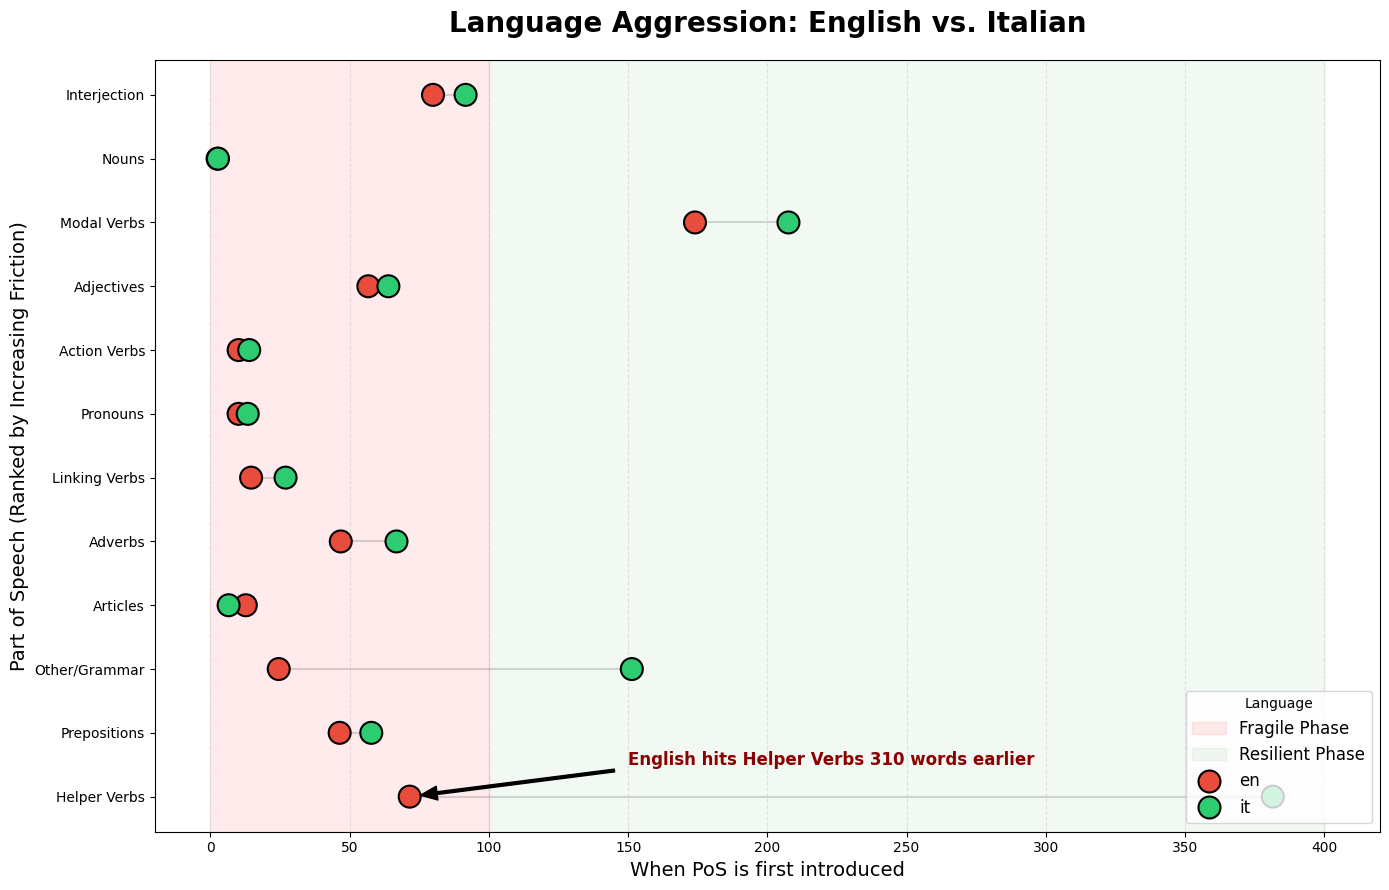

In [ ]:
pos_cols = [
    "Action Verbs",
    "Adjectives",
    "Adverbs",
    "Articles",
    "Helper Verbs",
    "Interjection",
    "Linking Verbs",
    "Modal Verbs",
    "Nouns",
    "Other/Grammar",
    "Prepositions",
    "Pronouns",
]

data = {
    "en": [
        10.11,
        56.70,
        46.79,
        12.69,
        71.55,
        79.92,
        14.59,
        174.00,
        2.55,
        24.51,
        46.39,
        10.10,
    ],
    "it": [
        13.91,
        63.90,
        66.81,
        6.52,
        381.50,
        91.62,
        26.97,
        207.57,
        2.69,
        151.31,
        57.75,
        13.38,
    ],
}

tox_order = [
    "Interjection",
    "Nouns",
    "Modal Verbs",
    "Adjectives",
    "Action Verbs",
    "Pronouns",
    "Linking Verbs",
    "Adverbs",
    "Articles",
    "Other/Grammar",
    "Prepositions",
    "Helper Verbs",
]

df_pos = pd.DataFrame(data, index=pos_cols).T
df_plot = df_pos[tox_order].reset_index().rename(columns={"index": "Language"})
df_melted = df_plot.melt(id_vars="Language", var_name="PoS", value_name="Interaction")

plt.figure(figsize=(14, 9))

plt.axvspan(0, 100, color="red", alpha=0.08, label="Fragile Phase")
plt.axvspan(100, 400, color="green", alpha=0.05, label="Resilient Phase")

for pos in tox_order:
    en_val = df_plot.loc[df_plot["Language"] == "en", pos].values[0]
    it_val = df_plot.loc[df_plot["Language"] == "it", pos].values[0]
    plt.plot(
        [en_val, it_val], [pos, pos], color="black", alpha=0.15, linestyle="-", zorder=1
    )

sns.scatterplot(
    data=df_melted,
    y="PoS",
    x="Interaction",
    hue="Language",
    palette={"en": "#E74C3C", "it": "#2ecc71"},  # Red (Aggressive) vs Green (Safe)
    s=250,
    edgecolor="black",
    linewidth=1.5,
    zorder=3,
)

plt.title(
    "Language Aggression: English vs. Italian", fontsize=20, fontweight="bold", pad=20
)
plt.xlabel("When PoS is first introduced", fontsize=14)
plt.ylabel("Part of Speech (Ranked by Increasing Friction)", fontsize=14)

plt.annotate(
    "English hits Helper Verbs 310 words earlier",
    xy=(71.5, "Helper Verbs"),
    xytext=(150, 10.5),
    arrowprops=dict(facecolor="black", shrink=0.05, width=2, headwidth=10),
    fontsize=12,
    fontweight="bold",
    color="darkred",
)

plt.legend(title="Language", loc="lower right", fontsize=12)
plt.grid(axis="x", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.savefig("aggression.jpg", dpi=300, bbox_inches="tight")
plt.show()

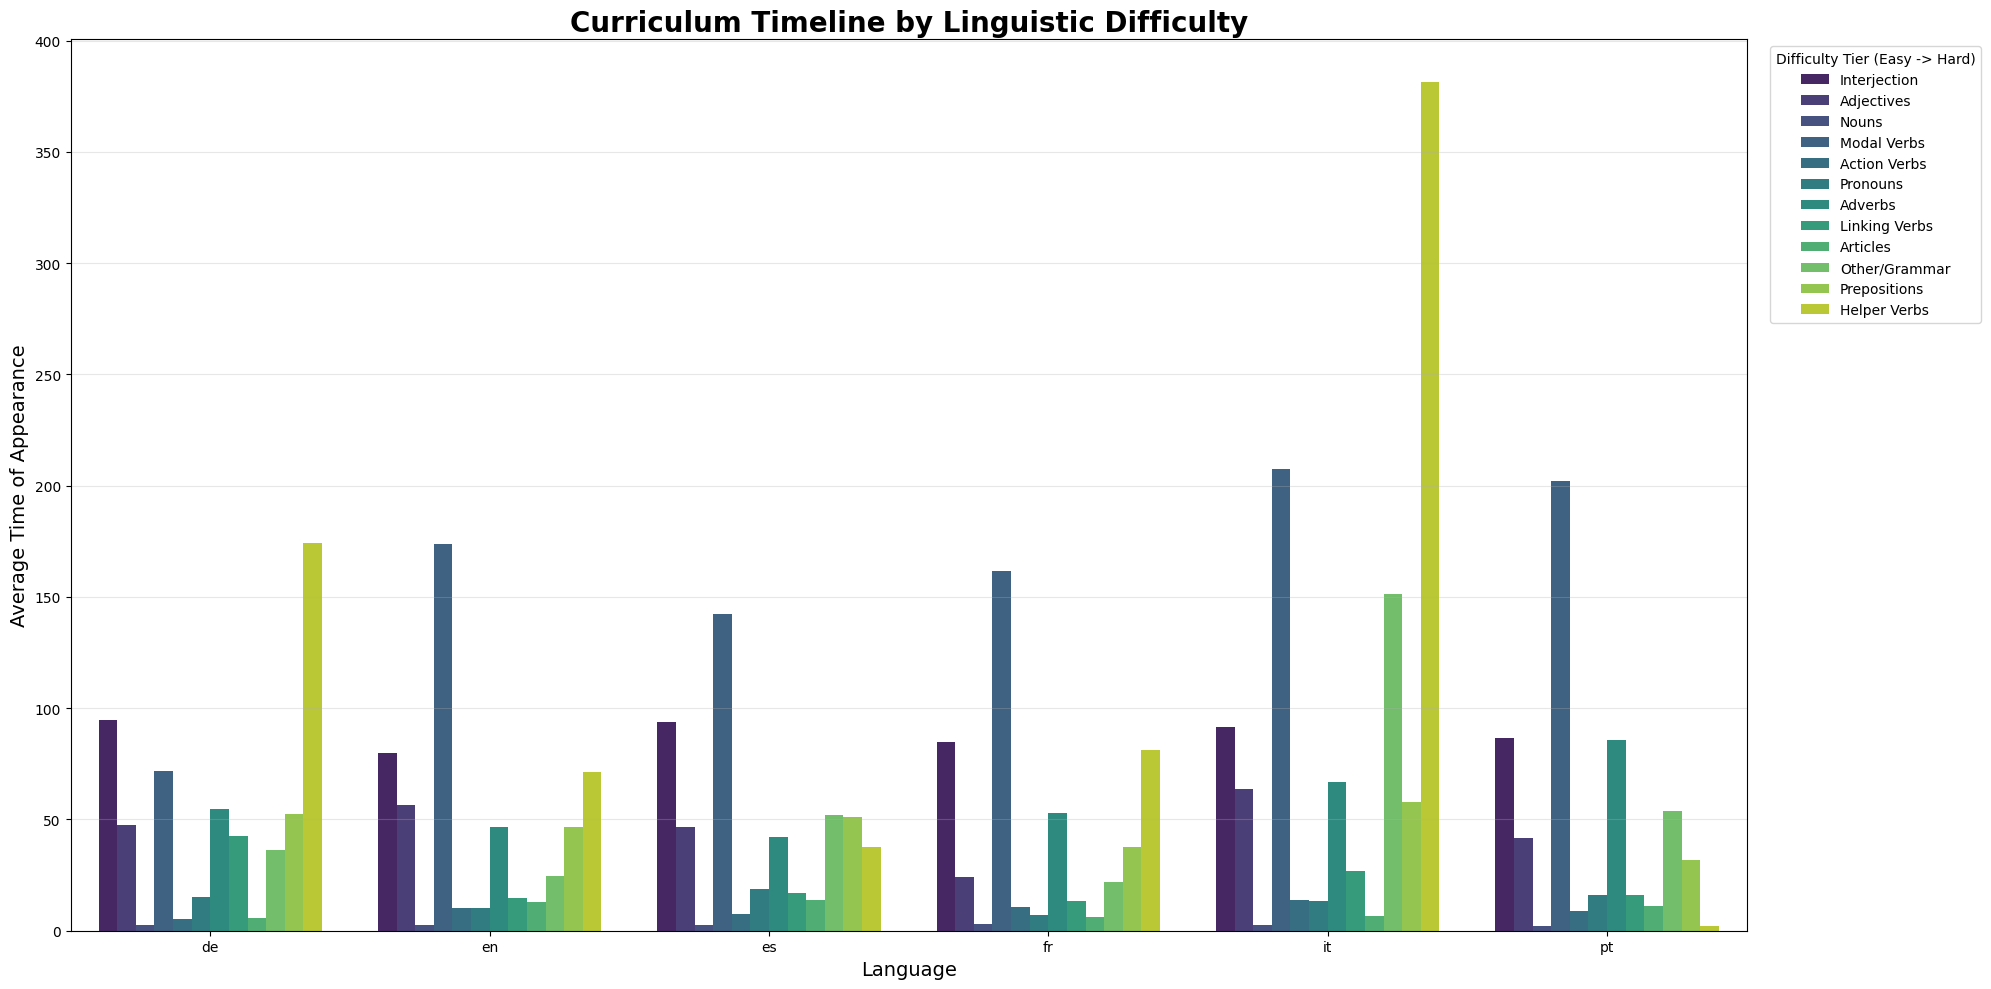

In [ ]:
difficulty_order = [
    "Interjection",
    "Adjectives",
    "Nouns",
    "Modal Verbs",
    "Action Verbs",
    "Pronouns",
    "Adverbs",
    "Linking Verbs",
    "Articles",
    "Other/Grammar",
    "Prepositions",
    "Helper Verbs",
]

pos_cols = [
    "Action Verbs",
    "Adjectives",
    "Adverbs",
    "Articles",
    "Helper Verbs",
    "Interjection",
    "Linking Verbs",
    "Modal Verbs",
    "Nouns",
    "Other/Grammar",
    "Prepositions",
    "Pronouns",
]

data = {
    "de": [
        5.45,
        47.51,
        54.90,
        5.50,
        174.25,
        94.66,
        42.55,
        71.57,
        2.38,
        36.40,
        52.35,
        15.28,
    ],
    "en": [
        10.11,
        56.70,
        46.79,
        12.69,
        71.55,
        79.92,
        14.59,
        174.00,
        2.55,
        24.51,
        46.39,
        10.10,
    ],
    "es": [
        7.29,
        46.42,
        42.02,
        13.81,
        37.67,
        93.97,
        17.04,
        142.22,
        2.55,
        52.09,
        51.06,
        18.73,
    ],
    "fr": [
        10.66,
        24.07,
        53.10,
        6.14,
        81.11,
        84.68,
        13.23,
        161.56,
        2.80,
        22.00,
        37.68,
        6.96,
    ],
    "it": [
        13.91,
        63.90,
        66.81,
        6.52,
        381.50,
        91.62,
        26.97,
        207.57,
        2.69,
        151.31,
        57.75,
        13.38,
    ],
    "pt": [
        8.64,
        41.60,
        85.63,
        11.23,
        2.00,
        86.82,
        16.12,
        201.94,
        2.20,
        53.89,
        31.94,
        16.13,
    ],
}

df_pos = pd.DataFrame(data, index=pos_cols).T
df_all_pos = df_pos.reset_index().melt(
    id_vars="index", var_name="PoS", value_name="Interaction"
)

plt.figure(figsize=(20, 10))

sns.barplot(
    data=df_all_pos,
    x="index",
    y="Interaction",
    hue="PoS",
    hue_order=difficulty_order,
    palette="viridis",
)

plt.title(
    "Curriculum Timeline by Linguistic Difficulty", fontsize=20, fontweight="bold"
)
plt.ylabel("Average Time of Appearance", fontsize=14)
plt.xlabel("Language", fontsize=14)

plt.legend(
    title="Difficulty Tier (Easy -> Hard)", bbox_to_anchor=(1.01, 1), loc="upper left"
)

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig("difficulty_ordered_pos.jpg", dpi=300, bbox_inches="tight")
plt.show()

/tmp/ipykernel_30727/3948692362.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


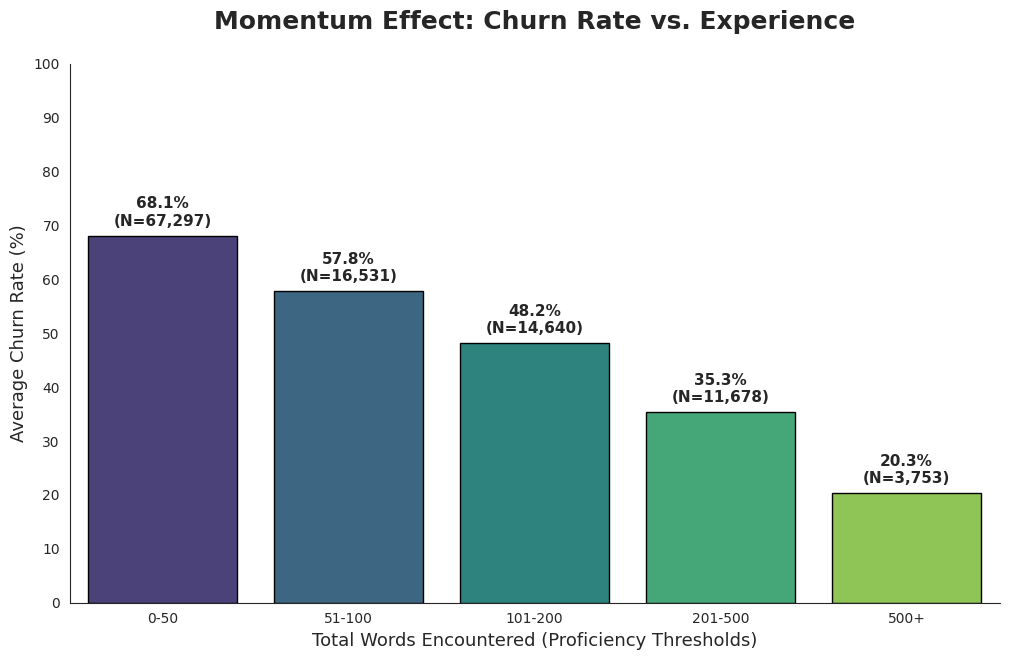

In [ ]:
user_summary = master_df.drop_duplicates(subset=["user_id"]).copy()

user_summary["word_bucket"] = pd.cut(
    user_summary["total_words_seen"],
    bins=[0, 50, 100, 200, 500, 1000],
    labels=["0-50", "51-100", "101-200", "201-500", "500+"],
)

survival_stats = (
    user_summary.groupby("word_bucket")
    .agg(churn_rate=("is_churned", "mean"), user_count=("user_id", "nunique"))
    .reset_index()
)

survival_stats["churn_rate_pct"] = survival_stats["churn_rate"] * 100

plt.figure(figsize=(12, 7))
sns.set_style("white")

ax = sns.barplot(
    data=survival_stats,
    x="word_bucket",
    y="churn_rate_pct",
    palette="viridis",
    edgecolor="black",
)

for i, p in enumerate(ax.patches):
    height = p.get_height()
    n_val = survival_stats.loc[i, "user_count"]

    ax.annotate(
        f"{height:.1f}%\n(N={int(n_val):,})",
        (p.get_x() + p.get_width() / 2.0, height),
        ha="center",
        va="bottom",
        xytext=(0, 5),
        textcoords="offset points",
        fontweight="bold",
        fontsize=11,
    )

plt.title(
    "Momentum Effect: Churn Rate vs. Experience", fontsize=18, fontweight="bold", pad=25
)
plt.ylabel("Average Churn Rate (%)", fontsize=13)
plt.xlabel("Total Words Encountered (Proficiency Thresholds)", fontsize=13)

plt.ylim(0, 100)
plt.yticks(range(0, 101, 10))

sns.despine()
plt.show()

In [ ]:
# Compare churn for those who quit BEFORE word 100
early_quitters = master_df[master_df["total_words_seen"] < 100]["is_churned"].mean()
long_term_users = master_df[master_df["total_words_seen"] >= 100]["is_churned"].mean()

print(f"\nChurn for users under 100 words: {early_quitters:.2%}")
print(f"Churn for users over 100 words: {long_term_users:.2%}")


Churn for users under 100 words: 66.09%
Churn for users over 100 words: 38.58%


English & French - highest avg_toxic_load and the highest churn rates 
high density of difficult words and early grammar spikes is likely creating a burnout that pushes users out

Italian has the lowest toxic load and lowest churn by keeping the honeymoon long and the toxicity low, effectively protecting users while they build a habit.

German & Portuguese have moderate toxicity but relatively controlled churn. indicating that while the curriculum might be aggressive, the users choosing these languages might have higher Intrinsic Motivation ??
